%pip install -U -q numpy pandas wfdb matplotlib notebook scikit-learn PyWavelets

In [7]:
import wfdb
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.linear_model import LinearRegression

import funkcje
from processor import Signal, ICP_ABP_Processor

## Sekcja wczytwania


Rekord: charis1
Długość: 12239851 próbek (68.0 h)
fs: 50 Hz, Kanały: 3
Nazwy kanałów: ['ABP', 'ECG', 'ICP']
[ICP] Szumy usunięte.
[ABP] Szumy usunięte.
[ICP] Sygnał przefiltrowany.
[ABP] Sygnał przefiltrowany.


NameError: name 'channel' is not defined

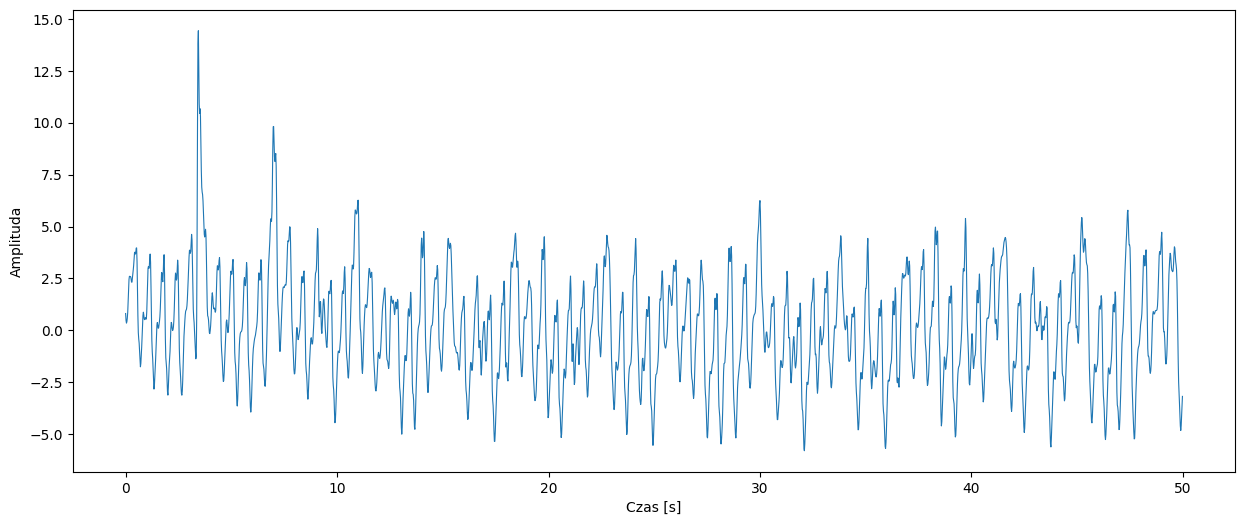

In [8]:
data_dir = 'charis-database-1.0.0'  # Lokalny folder
record_name = 'charis1'     # Nazwa rekordu (.hea i .dat)

os.makedirs(data_dir, exist_ok=True)

# TERAZ TWÓJ KOD BEZ ZMIAN
local_path = os.path.join(data_dir, record_name)

# Odczyt (automatycznie znajdzie .hea i .dat)
record = wfdb.rdrecord(local_path)

# Dane sygnałów
signals = record.p_signal  # NxM tablica (próbki x kanały)
fs = record.fs  # Częstotliwość próbkowania
time = np.arange(len(signals)) / fs # sekundy

print(f"Rekord: {record_name}")
print(f"Długość: {len(signals)} próbek ({len(signals)/fs/3600:.1f} h)")
print(f"fs: {fs} Hz, Kanały: {record.n_sig}")
print(f"Nazwy kanałów: {record.sig_name}")  # ['ABP', 'ECG', 'ICP']


channel_ABP = signals[:,0]
channel_ICP = signals[:,2]

# Inicjalizacja
processor = ICP_ABP_Processor(channel_ICP, channel_ABP, sampling_freq=50)
processor.process_all()

# # Pobieranie okien do dalszej analizy (np. korelacji PRx)
# okna_icp, okna_abp = processor.get_windowed_data(x_seconds_avg=5, window_size=60)
# PRx = calculate_PRx()


# Wizualizacja pierwszych 60s
plt.figure(figsize=(15, 6))
plt.plot(time[:int(50*fs)], processor.icp.data[:int(50*fs)], linewidth=0.8)
plt.xlabel('Czas [s]')
plt.ylabel('Amplituda')
plt.title(f'{record_name} kanał {record.sig_name[channel]}')
plt.grid(True, alpha=0.3)
plt.show()

# Zapis do CSV (opcjonalnie)
# np.savetxt('ecg_data.csv', np.column_stack([time, ecg]), delimiter=',', 
#            header='time_s,ecg_mv', comments='')
